# Problem Set 08

## Check for saddle-node, transcritical, or pitchfork bifurcations (look for determinant=0)

In [1]:
import sympy as sym
import numpy as np
from sympy import sqrt
from scipy.integrate import odeint

In [2]:
# Find fixed points
x = sym.symbols('x')
y = sym.symbols('y')
b = sym.symbols('b')
eq1 = sym.Eq(0, y + b*x)
eq2 = sym.Eq(0, -x + b*y - y*x**2 )
roots_xy = sym.solve([eq1,eq2],(x,y))
print(roots_xy)

# We will use this result later for plotting the fixed points.

[(0, 0), (-sqrt(b*(b**2 + 1))/b, sqrt(b*(b**2 + 1))), (sqrt(b*(b**2 + 1))/b, -sqrt(b*(b**2 + 1)))]


In [3]:
# define Jacobian matrix 
# (entered manually after computing the Jacobian separately)
# and find expressions for trace and determinant
jac = sym.Matrix([[b, 1], [-1-2*x*y, b-x**2]])
tr_jac = sym.Trace(jac).simplify()
det_jac = sym.det(jac).simplify()
print(tr_jac)
print(det_jac)

2*b - x**2
b**2 - b*x**2 + 2*x*y + 1


In [4]:
# identify zeros of the determinant for each fixed point
#  to check for saddle-node/transcritical/pitchfork bifurcations
bif_check = [None] * len(roots_xy)
for i in range(len(roots_xy)):
    (x0,y0) = roots_xy[i]
    bif_check[i] = sym.solve(det_jac.subs(x,x0).subs(y,y0), b)
    
print(bif_check)

[[-I, I], [-I, I], [-I, I]]


None of the fixed points in this system have Determinant zero at any real parameter value, so there are no saddle-node, transcritical, or pitchfork bifurcations.

## Check for Hopf bifurcation

In [5]:
# find parameter values where the trace is zero
#  as a later check, we'll look for determinant positive
hopf_check = [None] * len(roots_xy)
for i in range(len(roots_xy)):
    (x0,y0) = roots_xy[i]
    hopf_check[i] = sym.solve(tr_jac.subs(x,x0).subs(y,y0), b)

print(hopf_check)

[[0], [-1, 1], [-1, 1]]


Each of the fixed points has trace = 0 for at least one parameter value, so check the value of the determinant for each fixed point at the parameter values where the trace is zero 

In [6]:
# now look for a positive determinant at 
#  parameter values where trace was zero
for j in range(len(roots_xy)):
    for i in range(len(hopf_check[j])):
        (x0,y0) = roots_xy[j]
        b0 = hopf_check[j][i]
        val = det_jac.subs(x,x0).subs(y,y0).subs(b,b0)
        if val > 0:
            print(str("Zero trace and positive determinant when b ="),b0,str( "and (x,y) ="),(x0,y0))

Zero trace and positive determinant when b = 0 and (x,y) = (0, 0)


In [7]:
# for the fixed point involved in the bifurcation, check its stability
print(tr_jac.subs(x,0).subs(y,0))

# (0,0) is stable for b < 0 and unstable for b > 0.

2*b


### Is the bifurcation subcritical or supercritical?

If the bifurcation is *subcritical*, an **unstable limit cycle** is born at $b = b_c$ around the stable fixed point. No new limit cycle is created around the unstable fixed point.

If the bifurcation is *supercritical*, a **stable limit cycle** is born at $b = b_c$ around the unstable fixed point. No new limit cycle is created around the stable fixed point.

We will create trajectories to look for these limit cycles.

- Stay **close to the bifurcation value** $b = b_c$ so that the new limit cycle remains small.
- Use initial conditions **close to the fixed point**.
- Use **backward time integration** on the side with the stable fixed point so that an unstable limit cycle would be stabilized.
- Use **forward time integration** on the side with the unstable fixed point so that a stable limit cycle would be stable.


You should observe:
- One of the trajectories saturates at a small limit cycle (that is the side with the new limit cycle)
- The other trajectory may saturate at a larger limit cycle or may escape to infinity.

There may be other limit cycles in the system. Our goal is to isolate the **newly created cycle**, whose radius approaches zero at $b = b_c$. For this reason, keep both the parameter value and the initial condition close to the bifurcation point.

Flow is slow very close to the fixed point and very close to the bifurcation point, so we choose to be close, but not extremely close.

In [47]:
def forward_eq(t, xy, b0):
    x,y = xy
    dxds = y + b0*x
    dyds =  -x + b0*y - y*x**2 
    return [dxds, dyds]

def backward_eq(t, xy, b0):
    x,y = xy
    dxds = y + b0*x
    dyds =  -x + b0*y - y*x**2 
    return [-dxds, -dyds]

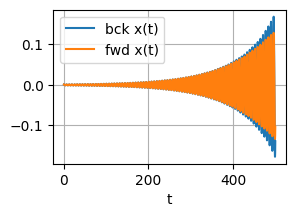

In [50]:
import matplotlib.pyplot as plt

# Checking for limit cycles

# fixed point is at (0,0), so start close to there.
x0 = [0.001, 0.0]
bcritical = 0
bdelta = 0.01
bstable = -1 # stable is below bcritical

# set a time range for integration
#  close to fixed points and bifurcations, dynamics can be slow
#   so integrate for a while
t0 = 0; tend = 500
s = np.linspace(t0,tend,1500)

#  look for a backward-stable limit cycle on 
#   the side where the fixed point is stable
bbk = bcritical + bstable*bdelta
solbklimcyc = solve_ivp(backward_eq, (t0, tend), x0,  args=(bbk,), t_eval=s)

#  look for a stable limit cycle on 
#   the side where the fixed point is unstable
bfwd = bcritical - bstable*bdelta
solfwdlimcyc = solve_ivp(forward_eq, (t0, tend), x0,  args=(bfwd,), t_eval=s)

# Plot the solutions

# With a limit cycle,
# we expect to spiral towards it, so x(t) and y(t) will have a max value
plt.figure(figsize=(3,2))
plt.plot(s, solbklimcyc.y[0],  label='bck x(t)')
plt.plot(s, solfwdlimcyc.y[0], label='fwd x(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

# The slower growing trajectory is likely going to approach the limit cycle.


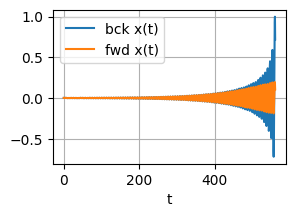

In [51]:
# Checking for limit cycles: adjust integration time

# increase the time range for integration to observe saturation
# tend = 600; s = np.linspace(0, tend, 1001) # Too long: caused integration error
# tend = 580; s = np.linspace(0, tend, 1001) # Too long: caused integration error
tend = 560; s = np.linspace(0, tend, 1001)

solbklimcyc = solve_ivp(backward_eq, (t0, tend), x0,  args=(bbk,), t_eval=s)
solfwdlimcyc = solve_ivp(forward_eq, (t0, tend), x0,  args=(bfwd,), t_eval=s)

plt.figure(figsize=(3,2))
plt.plot(s, solbklimcyc.y[0],  label='bck x(t)')
plt.plot(s, solfwdlimcyc.y[0], label='fwd x(t)')
plt.legend(loc='best')
plt.xlabel('t')
plt.grid()
plt.show()

# In this plot we can clearly see the backward time trajectory is growing outward
# and the forward time trajectory is saturating


### Make phase portraits on either side of the bifurcation

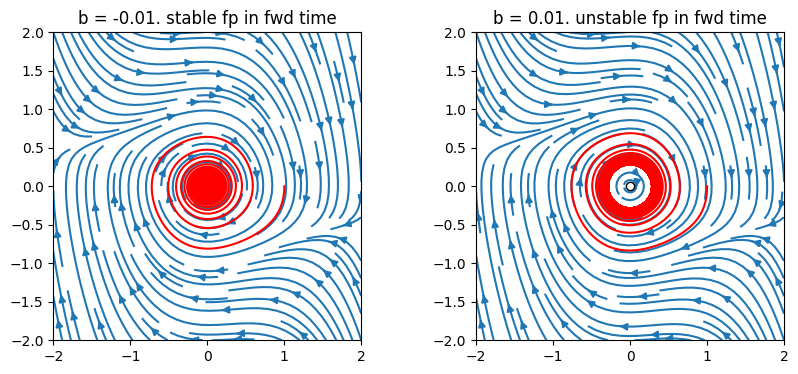

In [53]:
# For supercritical, use forward_eq
# For subcritical, use backward_eq
vectorfield_eq = forward_eq  # supercritical
# vectorfield_eq = backward_eq.  # subcritical

# use bifurcation info from above

# wrapper to evaluate the vector field on a grid
def vector_field(eq, X, Y, b0):
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            dx, dy = eq(0, [X[i, j], Y[i, j]], b0)
            U[i, j] = dx
            V[i, j] = dy
            
    return U, V

# grid: the -2 and 2 set the limits of the plot 
# (so adjust to move the axis range)
xmin = -2
xmax = 2
ymin = -2
ymax = 2
x = np.linspace(xmin, xmax, 200)
y = np.linspace(xmin, xmax, 200)
X, Y = np.meshgrid(x, y)

# create the two vector fields (on either side of the bifurcation)
U_f1, V_f1 = vector_field(vectorfield_eq, X, Y, bbk)
U_f2, V_f2 = vector_field(vectorfield_eq, X, Y, bfwd)

# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].streamplot(X, Y, U_f1, V_f1, density=1.2)
axes[0].set_title(f"b = {bbk}. stable fp in fwd time")

axes[1].streamplot(X, Y, U_f2, V_f2, density=1.2)
axes[1].set_title(f"b = {bfwd}. unstable fp in fwd time")

# add fixed points.  
# for this example the only visible fp stays at (0,0) even as b changes
xp = 0; yp = 0
axes[0].plot(xp, yp, 'o', markerfacecolor='black', markeredgecolor='black')
axes[1].plot(xp, yp, 'o', markerfacecolor='none', markeredgecolor='black')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])

# initial condition and time grid
x0 = [1.0, 0.0]
t0, tend, tpoints = 0, 500, 10000
s = np.linspace(t0, tend, tpoints)  # need lots of points for smooth curves

# parameter values matched to axes order
b_vals = [bbk, bfwd]

# integrate and plot trajectories
for ax, b_val in zip(axes, b_vals):
    sol = solve_ivp(vectorfield_eq, (t0, tend), x0,  args=(b_val,), t_eval=s)
    ax.plot(sol.y[0], sol.y[1], 'r')



## Poincaré map example

We'll use a vertical line segment above the fixed point as the curve on which trajectories start and stop

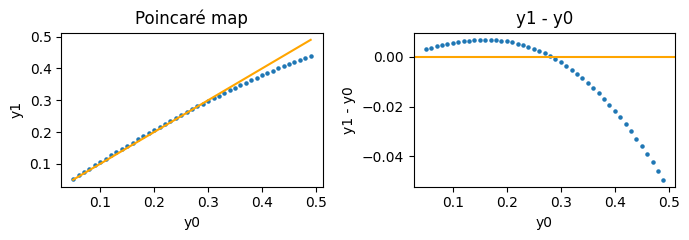

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Change these for a new system or new fixed point
m = 0.01
fixed_point = np.array([1.0, 0.0])   # [x_fp, y_fp]
# integration time needs to be long enough to return
#  if things look weird, plot a trajectory
t_span = (0.0, 50.0)    

# create the section by fixing x and creating a range of y
ymin = 0.05; ymax = 0.5; ystep = 0.01
section_y0_vals = np.arange(fixed_point[1] + ymin, fixed_point[1] + ymax, ystep)

push_off_time = 1e-5
rtol = 1e-8
atol = 1e-10

def dynamics(t, state, m):
    x, y = state
    dxdt = y + m * (x-1)
    dydt = -(x-1) + m * y - (x-1)**2 * y
    return [dxdt, dydt]

def hit_section(t, state, m):
    # hit the section when x returns to fixed_point value
    # and y is above its fixed_point value
    x, y = state
    return x - fixed_point[0]

hit_section.terminal = True
# direction is 1 for clockwise flow, -1 for counterclockwise
hit_section.direction = 1 

y1_vals = []

for y0 in y0_vals:
    start_state = [fixed_point[0], y0]

    # integrate to move slightly off the section first
    sol0 = solve_ivp(
        dynamics, (0.0, push_off_time), start_state,
        args=(m,), rtol=rtol, atol=atol
    )

    # then integrate until first return to the section
    #  it is critical to set hit_section.direction correctly
    sol = solve_ivp(
        dynamics, t_span, sol0.y[:, -1],
        args=(m,), events=hit_section, dense_output=True,
        rtol=rtol, atol=atol
    )

    if len(sol.t_events[0]) == 0:
        y1_vals.append(np.nan)
    else:
        t_return = sol.t_events[0][0]
        y1_vals.append(sol.sol(t_return)[1])

y1_vals = np.array(y1_vals)

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# Poincaré map
axes[0].plot(y0_vals, y0_vals, color='orange')
axes[0].scatter(y0_vals, y1_vals, s=5) # s=size
axes[0].set_xlabel('y0')
axes[0].set_ylabel('y1')
axes[0].set_title('Poincaré map')

# y1 - y0 plot
# the limit cycle is much more visible in this plot
axes[1].scatter(y0_vals, y1_vals - y0_vals, s=5)
axes[1].axhline(0, color='orange')
axes[1].set_xlabel('y0')
axes[1].set_ylabel('y1 - y0')
axes[1].set_title('y1 - y0')

plt.tight_layout()
plt.show()